# Introduction
In this notebook we will evaluate the models for forecasting the demand of retail products. The best performing model will be deployed to power the demand forecasting dashboard for <a href = "https://walmart.converge.tech/content/converge/en_in/sparkathon.html"><b>Sparathon Challange</b></a> solution we are building.

The data to train and evaluate the forecasting models is taken from a <a href = "https://www.kaggle.com/competitions/m5-forecasting-accuracy/overview"><b>kaggle challange</b></a> hosted by University of Nicosia. The dataset consists of following files:
<ul>
    <li>calendar.csv : Contains the information about dates on which products are sold.</li>
    <li>sales_train_validation.csv : Contains the historical daily unit sales data per product and store [d_1 - d_1913]</li>
    <li>sell_prices.csv : Contains information about the price of the products sold per store and date.</li>
    <li>sales_train_evaluation.csv - Includes sales [d_1 - d_1941]</li>
</ul>

<u><b>Note</b></u> : The demand volume is proxied with the sales value of the products in the data for the purposes of our solution.

In [1]:
# Library Imports
import pandas as pd
import numpy as np
from datetime import datetime
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout, Conv1D, BatchNormalization, Flatten, ConvLSTM1D
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.losses import MAPE
from sklearn.metrics import mean_absolute_percentage_error
import scipy.stats as stats

2024-08-15 12:23:17.803275: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-08-15 12:23:17.803421: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-08-15 12:23:17.940984: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
# Notebook Runtime Parameters
data_directory = "/kaggle/input/m5-forecasting-accuracy/"
calendar_file_name = "calendar.csv"
sales_evaluation_file_name = "sales_train_evaluation.csv"
sales_validation_file_name = "sales_train_validation.csv"
# historical_sell_prices_file_name = "sell_prices.csv"

forecast_horizon = 28 # Forecast for 4-weeks ahead.
lookback_window = 7 # Take data from previous 1-weeks as input

In [3]:
# Reading the data from the input CSV files.
calendar_data = pd.read_csv(data_directory + calendar_file_name)
# sales_evaluation_data = pd.read_csv(data_directory + sales_evaluation_file_name)
sales_validation_data = pd.read_csv(data_directory + sales_validation_file_name)
# sell_prices_data = pd.read_csv(data_directory + historical_sell_prices_file_name)

# Reduce Memory Usage

In [4]:
def reduce_mem_usage(df):
    """ iterate through all the columns of a dataframe and modify the data type
        to reduce memory usage.        
    """
    start_mem = df.memory_usage().sum() / 1024**2
    print('Memory usage of dataframe is {:.2f} MB'.format(start_mem))
    
    for col in df.columns:
        col_type = df[col].dtype
        
        if col_type != object:
            c_min = df[col].min()
            c_max = df[col].max()
            if str(col_type)[:3] == 'int':
                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)
                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)
                elif c_min > np.iinfo(np.int64).min and c_max < np.iinfo(np.int64).max:
                    df[col] = df[col].astype(np.int64)  
            else:
                if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
                    df[col] = df[col].astype(np.float16)
                elif c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                    df[col] = df[col].astype(np.float32)
                else:
                    df[col] = df[col].astype(np.float64)
        else:
            df[col] = df[col].astype('category')

    end_mem = df.memory_usage().sum() / 1024**2
    print('Memory usage after optimization is: {:.2f} MB'.format(end_mem))
    print('Decreased by {:.1f}%'.format(100 * (start_mem - end_mem) / start_mem))
    
    return df

# sales_evaluation_data = reduce_mem_usage(sales_evaluation_data)
sales_validation_data = reduce_mem_usage(sales_validation_data)

Memory usage of dataframe is 446.40 MB
Memory usage after optimization is: 95.16 MB
Decreased by 78.7%


In [5]:
# Inspecting Volume of data in each files.
print("Calendar Data : ", calendar_data.shape)
# print("Evaluation Data : ", sales_evaluation_data.shape)
print("Validation Data : ", sales_validation_data.shape)
# print("Sell Prices Data : ", sell_prices_data.shape)

Calendar Data :  (1969, 14)
Validation Data :  (30490, 1919)


In [6]:
calendar_data.head()

,date,wm_yr_wk,weekday,wday,month,year,d,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
0,2011-01-29,11101,Saturday,1,1,2011,d_1,NaN,NaN,NaN,NaN,0,0,0
1,2011-01-30,11101,Sunday,2,1,2011,d_2,NaN,NaN,NaN,NaN,0,0,0
2,2011-01-31,11101,Monday,3,1,2011,d_3,NaN,NaN,NaN,NaN,0,0,0
3,2011-02-01,11101,Tuesday,4,2,2011,d_4,NaN,NaN,NaN,NaN,1,1,0
4,2011-02-02,11101,Wednesday,5,2,2011,d_5,NaN,NaN,NaN,NaN,1,0,1


In [7]:
# sell_prices_data.head()

In [8]:
sales_validation_data.head()

,id,item_id,dept_id,cat_id,store_id,state_id,d_1,d_2,d_3,d_4,...,d_1904,d_1905,d_1906,d_1907,d_1908,d_1909,d_1910,d_1911,d_1912,d_1913
0,HOBBIES_1_001_CA_1_validation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,3,0,1,1,1,3,0,1,1
1,HOBBIES_1_002_CA_1_validation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
2,HOBBIES_1_003_CA_1_validation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,2,1,2,1,1,1,0,1,1,1
3,HOBBIES_1_004_CA_1_validation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,0,5,4,1,0,1,3,7,2
4,HOBBIES_1_005_CA_1_validation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,2,1,1,0,1,1,2,2,2,4


In [9]:
# sales_evaluation_data.head()

In [10]:
# sell_prices_data["store_id"].value_counts()

In [11]:
sales_validation_data[sales_validation_data["cat_id"] == 'FOODS']["item_id"].unique()

['FOODS_1_001', 'FOODS_1_002', 'FOODS_1_003', 'FOODS_1_004', 'FOODS_1_005', ..., 'FOODS_3_823', 'FOODS_3_824', 'FOODS_3_825', 'FOODS_3_826', 'FOODS_3_827']
Length: 1437
Categories (3049, object): ['FOODS_1_001', 'FOODS_1_002', 'FOODS_1_003', 'FOODS_1_004', ..., 'HOUSEHOLD_2_513', 'HOUSEHOLD_2_514', 'HOUSEHOLD_2_515', 'HOUSEHOLD_2_516']

# Transform (Wide to Long format)
The sales validation and evaluation data is transformed such that data is in row-event format.

In [12]:
sales_validation_data = pd.melt(sales_validation_data, id_vars = ['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id'], var_name = 'd', value_name = 'sales')
# sales_evaluation_data = pd.melt(sales_evaluation_data, id_vars = ['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id'], var_name = 'd', value_name = 'sales')

# Adding Calendar information
The date information related to product sales is added. 

In [13]:
sales_validation_data = sales_validation_data.merge(calendar_data, on = "d", how = "left")
# sales_evaluation_data = sales_evaluation_data.merge(calendar_data, on = "d", how = "left")

# Concatenate Data
Concatenated the datasets for harmonized of view of data. The train-test split will be made in out-of-time manner. 

In [14]:
# data = pd.concat([sales_validation_data, sales_evaluation_data], axis = 0, ignore_index = True)
data = sales_validation_data.copy()

In [15]:
del sales_validation_data
# del sales_evaluation_data

In [16]:
pd.to_datetime(data["date"]).min(), pd.to_datetime(data["date"]).max()

(Timestamp('2011-01-29 00:00:00'), Timestamp('2016-04-24 00:00:00'))

In [17]:
data['date'] = pd.to_datetime(data["date"])
items_list = data[data["cat_id"] == 'FOODS']["item_id"].unique().tolist()[ : 10]
stores_list = data[data["cat_id"] == 'FOODS']["store_id"].unique().tolist()

data = data[
#     (data["date"] >= datetime.strptime("2011-01-01", "%Y-%m-%d")) &
    (data["item_id"].isin(items_list)) &
    (data["store_id"].isin(stores_list))
]

In [18]:
data.shape

(191300, 21)

# Lag based and Moving Window Average Features  

In [19]:
def create_features(dt, lags = [lookback_window], wins = [lookback_window]):
    lag_cols = [f"lag_{lag}" for lag in lags]
    for lag, lag_col in zip(lags, lag_cols):
        dt[lag_col] = dt[["id","sales"]].groupby("id")["sales"].shift(lag).fillna(-1)

    for win in wins :
        for lag,lag_col in zip(lags, lag_cols):
            dt[f"rmean_{lag}_{win}"] = dt[["id", lag_col]].groupby("id")[lag_col].transform(lambda x : x.rolling(win).mean()).fillna(-1)
        
    return dt

data = create_features(data)

/tmp/ipykernel_25/2017246496.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dt[lag_col] = dt[["id","sales"]].groupby("id")["sales"].shift(lag).fillna(-1)
/tmp/ipykernel_25/2017246496.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dt[f"rmean_{lag}_{win}"] = dt[["id", lag_col]].groupby("id")[lag_col].transform(lambda x : x.rolling(win).mean()).fillna(-1)


# Time based Features

In [20]:
date_features = {
        
        "wday": "weekday",
        "week": "weekofyear",
        "month": "month",
        "quarter": "quarter",
        "year": "year",
        "mday": "day",

    }
    
for date_feat_name, date_feat_func in date_features.items():
    if date_feat_name in data.columns:
        data[date_feat_name] = data[date_feat_name].astype("int16")
    else:
        if date_feat_name == 'week':
            data[date_feat_name] = data["date"].dt.isocalendar().week
        else:
            data[date_feat_name] = getattr(data["date"].dt, date_feat_func).astype("int16")

# Label encoding ID columns

In [21]:
# encode categorical features
cat_feats = ['item_id', 'dept_id','store_id', 'cat_id']
le_encoder_map = {}
for cc in cat_feats:
    le = LabelEncoder()
    data[cc] = le.fit_transform(data[cc])
    le_encoder_map[cc] = le

# Feature Scaling

In [22]:
# Feature Scaling
# scaler = StandardScaler()
# scaled_features = ['rmean_7_7', 'lag_7']
# data[scaled_features] = scaler.fit_transform(data[scaled_features])

# Sort the data by Date

In [23]:
data.sort_values(['item_id', 'store_id', 'date'], inplace=True)

# Train-Validation Split

In [24]:
# split into train and test
cutoff = data.date.max() - pd.to_timedelta(forecast_horizon + lookback_window, unit = 'D')
xtrain = data.loc[data.date < cutoff].copy()
xeval = data.loc[data.date >= cutoff].copy()

xtrain.shape, xeval.shape

((187700, 26), (3600, 26))

In [25]:
drop_columns = ['id', 'state_id', 'd', 'date', 'weekday', 'wm_yr_wk', 'event_name_1', 'event_type_1', 'event_name_2', 'event_type_2']
feature_columns = list(set(xtrain.columns).difference(set(drop_columns)))
target_column = "sales"


scalerX = StandardScaler()
scalerY = StandardScaler()

In [26]:
# def create_timeseries(df, le_encoder_map, items_list, stores_list, feature_columns, target_column, stride = 1):
#     global scalerX
#     X = []
#     Y = []
#     for item_id in items_list:
#         for store_id in stores_list:
#             temp = df[
#                 (df["item_id"] == le_encoder_map["item_id"].transform([item_id])[-1]) &
#                 (df["store_id"] == le_encoder_map["store_id"].transform([store_id])[-1])
#             ]
#             start_date = temp["date"].min()
#             end_date = temp["date"].max()
#             while(start_date <= end_date):
#                 filtered_temp = temp[
#                     (temp["date"] >= start_date) & 
#                     (temp["date"] < start_date + pd.to_timedelta(lookback_window + 1, unit = 'D'))
#                 ].reset_index(drop = True)
#                 if filtered_temp.shape[0] < lookback_window + 1:
#                     del filtered_temp
#                     start_date += pd.to_timedelta(lookback_window, unit = 'D')
#                 else:
#                     for idx in range(0, filtered_temp.shape[0] - lookback_window + 2, lookback_window):
#                         d_i = filtered_temp.loc[idx : idx + lookback_window - 1, : ][feature_columns].values
#                         d_o = filtered_temp.loc[idx + lookback_window, : ][target_column].sum()
#                         scalerX = scalerX.partial_fit(d_i)
#                         X.append(scalerX.transform(d_i))
#                         Y.append(d_o)
#                     del filtered_temp
#                     start_date += pd.to_timedelta(lookback_window, unit = 'D')
#             del temp
#     return np.array(X).astype(float), np.array(Y).astype(float)

In [27]:
def create_timeseries(df, le_encoder_map, items_list, stores_list, feature_columns, target_column, stride = 1):
    global scalerX
    X = []
    Y = []
    dates = []
    for item_id in items_list:
#         for store_id in stores_list:
        temp = df[
            (df["item_id"] == le_encoder_map["item_id"].transform([item_id])[-1]) #&
#             (df["store_id"] == le_encoder_map["store_id"].transform([store_id])[-1])
        ]
        start_date = temp["date"].min()
        end_date = temp["date"].max()
        while(start_date <= end_date):
            filtered_temp = temp[
                (temp["date"] >= start_date) & 
                (temp["date"] < start_date + pd.to_timedelta(lookback_window * 2, unit = 'D'))
            ].reset_index(drop = True)
            if filtered_temp.shape[0] < lookback_window * 2:
                del filtered_temp
                start_date += pd.to_timedelta(lookback_window, unit = 'D')
            else:
                for idx in range(0, filtered_temp.shape[0] - lookback_window + 1, lookback_window):
                    d_i = filtered_temp.loc[idx : idx + lookback_window - 1, : ][feature_columns].values
                    d_o = filtered_temp.loc[idx + lookback_window + 1 : , : ][target_column].sum()
                    dates.append(filtered_temp.loc[idx + lookback_window + 1 : , : ]["date"].max())
                    scalerX = scalerX.partial_fit(d_i)
                    X.append(scalerX.transform(d_i))
                    Y.append(d_o)
                del filtered_temp
                start_date += pd.to_timedelta(lookback_window, unit = 'D')
        del temp
    return np.array(X).astype(float), np.array(Y).astype(float), np.array(dates)

In [28]:
X_train, Y_train, dates_train = create_timeseries(xtrain, le_encoder_map, items_list, stores_list, feature_columns, target_column)
X_eval, Y_eval, dates_eval = create_timeseries(xeval, le_encoder_map, items_list, stores_list, feature_columns, target_column)

In [29]:
X_train.shape, Y_train.shape, X_eval.shape, Y_eval.shape

((53510, 7, 16), (53510,), (910, 7, 16), (910,))

# Training the model

## LSTM Model

In [30]:

# Set up the model
lstm_input = Input(shape = (lookback_window, len(feature_columns)))

# Add LSTM layers
lstm_1 = LSTM(512, activation='relu', return_sequences=True)(lstm_input)
lstm_dropout_1 = Dropout(0.2)(lstm_1)
lstm_2 = LSTM(256, activation='relu', return_sequences=True)(lstm_dropout_1)
lstm_dropout_2 = Dropout(0.2)(lstm_2)
lstm_3 = LSTM(128, activation='relu', return_sequences=True)(lstm_dropout_2)
lstm_dropout_3 = Dropout(0.2)(lstm_3)
lstm_2 = LSTM(64, activation='relu', return_sequences=False)(lstm_dropout_3)
lstm_dropout_2 = Dropout(0.2)(lstm_2)
lstm_dense_1 = Dense(64, activation = "relu")(lstm_dropout_2)
lstm_dense_dropout_1 = Dropout(0.2)(lstm_dense_1)
lstm_dense_2 = Dense(32, activation = "relu")(lstm_dense_dropout_1)
lstm_dense_dropout_2 = Dropout(0.2)(lstm_dense_2)
lstm_dense_3 = Dense(16, activation = "relu")(lstm_dense_dropout_2)
lstm_dense_dropout_3 = Dropout(0.2)(lstm_dense_3)
lstm_dense_4 = Dense(8, activation = "relu")(lstm_dense_dropout_3)
lstm_dense_dropout_4 = Dropout(0.2)(lstm_dense_4)
lstm_output = Dense(1)(lstm_dense_dropout_4)

lstm_model = Model(lstm_input, lstm_output)
                   
# Compile the model
lstm_model.compile(optimizer='adam', loss='mse', metrics = ['mape'])

# Early stopping to prevent overfitting
early_stopping = EarlyStopping(monitor='loss', patience=10, restore_best_weights=True)

# Train the model
history = lstm_model.fit(X_train, Y_train, validation_data=(X_eval, Y_eval), batch_size = 128, epochs=500, shuffle = True, 
                    callbacks=[early_stopping])

# Evaluate the model
loss = lstm_model.evaluate(X_eval, Y_eval)

# You can now make predictions using the trained model
lstm_predictions = lstm_model.predict(X_eval)

# Calculate MAPE
mape = mean_absolute_percentage_error(Y_eval, lstm_predictions)

print(f'Test Loss (MSE) : {loss}')
print(f'Test Loss (MAPE) : {mape}')

Epoch 1/500
 11/419 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 57977.3945 - mape: 23709136.0000

I0000 00:00:1723724844.384418      68 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


419/419 ━━━━━━━━━━━━━━━━━━━━ 50s 58ms/step - loss: 36826.0586 - mape: 3739529216.0000 - val_loss: 1860.7905 - val_mape: 2542382336.0000
Epoch 2/500
419/419 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 22838.7148 - mape: 3939699968.0000 - val_loss: 1941.4491 - val_mape: 2406076416.0000
Epoch 3/500
419/419 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 18049.8340 - mape: 3438680832.0000 - val_loss: 1832.1395 - val_mape: 4840635392.0000
Epoch 4/500
419/419 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 18483.3965 - mape: 3711958272.0000 - val_loss: 2197.1619 - val_mape: 4194985984.0000
Epoch 5/500
419/419 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 15079.4619 - mape: 3412423424.0000 - val_loss: 2626.1040 - val_mape: 6340507648.0000
Epoch 6/500
419/419 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 15684.1836 - mape: 3578683904.0000 - val_loss: 2239.7778 - val_mape: 3771410944.0000
Epoch 7/500
419/419 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 15630.2676 - mape: 3423388672.0000 - val_loss: 5559.0664 - val_mape

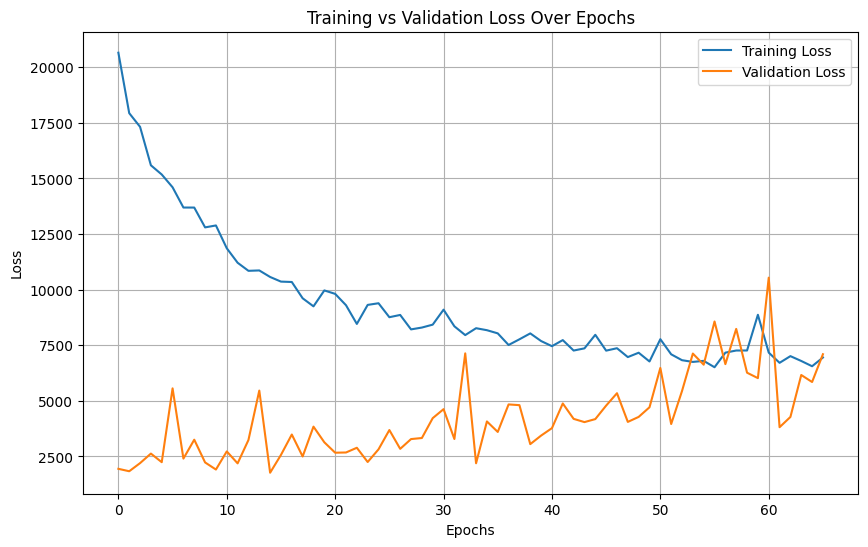

In [31]:
from matplotlib import pyplot as plt
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'][1 : ], label='Training Loss')
plt.plot(history.history['val_loss'][1 : ], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss Over Epochs')
plt.legend()
plt.grid(True)
plt.show()

## Convolution Model

In [32]:
# Set up the model
conv_input = Input(shape = (lookback_window, len(feature_columns)))

# Add Conv layers
conv_1 = Conv1D(8, 3, padding = "same", activation = "relu")(conv_input)
conv_2 = Conv1D(16, 3, padding = "same", activation = "relu")(conv_1)
conv_batch_norm_1 = BatchNormalization()(conv_2)
conv_3 = Conv1D(32, 3, padding = "same", activation = "relu")(conv_batch_norm_1)
conv_4 = Conv1D(64, 3, padding = "same", activation = "relu")(conv_3)
conv_batch_norm_2 = BatchNormalization()(conv_4)
conv_flat = Flatten()(conv_batch_norm_2)
conv_dense_1 = Dense(64 * lookback_window, activation = 'relu')(conv_flat)
conv_dense_dropout_1 = Dropout(0.2)(conv_dense_1)
conv_dense_2 = Dense(32, activation = "relu")(conv_dense_dropout_1)
conv_dense_dropout_2 = Dropout(0.2)(conv_dense_2)
conv_dense_3 = Dense(16, activation = "relu")(conv_dense_dropout_2)
conv_dense_dropout_3 = Dropout(0.2)(conv_dense_3)
conv_dense_4 = Dense(8, activation = "relu")(conv_dense_dropout_3)
conv_dense_dropout_4 = Dropout(0.2)(conv_dense_4)
conv_output = Dense(1)(conv_dense_dropout_4)


conv_model = Model(conv_input, conv_output)

# print(model.summary())
                   
# Compile the model
conv_model.compile(optimizer='adam', loss='mse', metrics = ['mape'])

# Early stopping to prevent overfitting
early_stopping = EarlyStopping(monitor='loss', patience=10, restore_best_weights=True)

# Train the model
history = conv_model.fit(X_train, Y_train, validation_data=(X_eval, Y_eval), batch_size = 512, shuffle = True,epochs=500, 
                    callbacks=[early_stopping])

# Evaluate the model
loss = conv_model.evaluate(X_eval, Y_eval)

# You can now make predictions using the trained model
conv_predictions = conv_model.predict(X_eval)

# Calculate MAPE
mape = mean_absolute_percentage_error(Y_eval, conv_predictions)

print(f'Test Loss (MSE) : {loss}')
print(f'Test Loss (MAPE) : {mape}')

Epoch 1/500
105/105 ━━━━━━━━━━━━━━━━━━━━ 24s 107ms/step - loss: 40451.9844 - mape: 2120620288.0000 - val_loss: 2821.9236 - val_mape: 720217600.0000
Epoch 2/500
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 23301.7441 - mape: 3844367616.0000 - val_loss: 2066.2844 - val_mape: 2390676480.0000
Epoch 3/500
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 19667.1719 - mape: 3767098880.0000 - val_loss: 1806.4230 - val_mape: 5436038144.0000
Epoch 4/500
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 16824.9805 - mape: 3486527744.0000 - val_loss: 2200.4697 - val_mape: 4821123072.0000
Epoch 5/500
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 16364.2129 - mape: 3241449472.0000 - val_loss: 2014.9849 - val_mape: 4845445632.0000
Epoch 6/500
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 15857.3525 - mape: 3204684800.0000 - val_loss: 2751.1670 - val_mape: 3910040320.0000
Epoch 7/500
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 14329.7559 - mape: 2837800448.0000 - val_loss: 1910.8169 - va

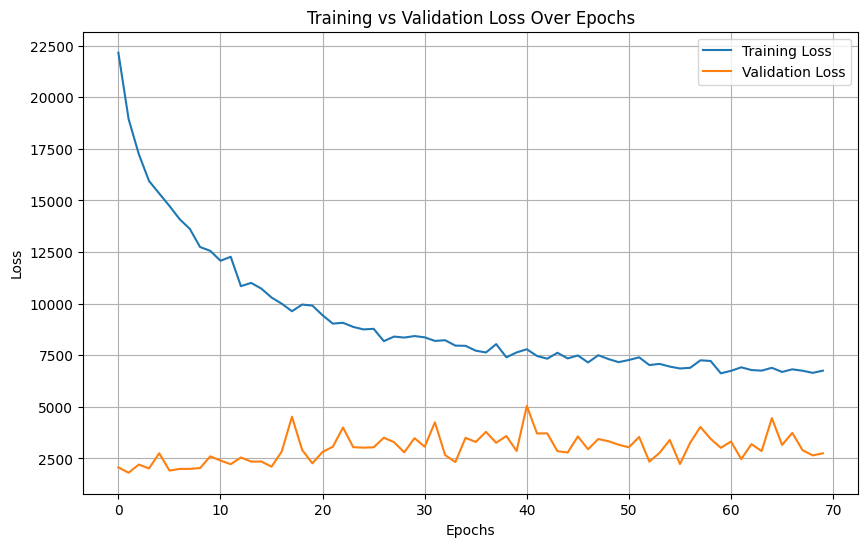

In [33]:
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'][1 : ], label='Training Loss')
plt.plot(history.history['val_loss'][1 : ], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss Over Epochs')
plt.legend()
plt.grid(True)
plt.show()

## Conv-LSTM Model

In [34]:
# Set up the model
conv_lstm_input = Input(shape = (1, lookback_window, len(feature_columns)))

# Add Layers

conv_lstm_1 = ConvLSTM1D(
    filters=64,
    kernel_size=5,
    padding="same",
    return_sequences=True,
    activation="relu",
)(conv_lstm_input)
conv_lstm_batch_norm_1 = BatchNormalization()(conv_lstm_1)
conv_lstm_2 = ConvLSTM1D(
    filters=64,
    kernel_size=3,
    padding="same",
    return_sequences=True,
    activation="relu",
)(conv_lstm_batch_norm_1)
conv_lstm_batch_norm_2 = BatchNormalization()(conv_lstm_2)
conv_flat = Flatten()(conv_lstm_batch_norm_2)
conv_dense_1 = Dense(64 * lookback_window, activation = 'relu')(conv_flat)
conv_dense_dropout_1 = Dropout(0.2)(conv_dense_1)
conv_dense_2 = Dense(32, activation = "relu")(conv_dense_dropout_1)
conv_dense_dropout_2 = Dropout(0.2)(conv_dense_2)
conv_dense_3 = Dense(16, activation = "relu")(conv_dense_dropout_2)
conv_dense_dropout_3 = Dropout(0.2)(conv_dense_3)
conv_dense_4 = Dense(8, activation = "relu")(conv_dense_dropout_3)
conv_dense_dropout_4 = Dropout(0.2)(conv_dense_4)
conv_output = Dense(1)(conv_dense_dropout_4)

conv_lstm_model = Model(conv_lstm_input, conv_output)
# model.summary()

# Compile the model
conv_lstm_model.compile(optimizer='adam', loss='mse', metrics = ['mape'])

# Early stopping to prevent overfitting
early_stopping = EarlyStopping(monitor='loss', patience=10, restore_best_weights=True)

# Train the model
history = conv_lstm_model.fit(X_train.reshape(-1, 1, lookback_window, len(feature_columns)), Y_train, validation_data=(X_eval.reshape(-1, 1, lookback_window, len(feature_columns)), Y_eval), batch_size = 512, shuffle = True,epochs=500, 
                    callbacks=[early_stopping])

# Evaluate the model
loss = conv_lstm_model.evaluate(X_eval.reshape(-1, 1, lookback_window, len(feature_columns)), Y_eval)

# You can now make predictions using the trained model
conv_lstm_predictions = conv_lstm_model.predict(X_eval.reshape(-1, 1, lookback_window, len(feature_columns)))

# Calculate MAPE
mape = mean_absolute_percentage_error(Y_eval, conv_predictions)

print(f'Test Loss (MSE) : {loss}')
print(f'Test Loss (MAPE) : {mape}')

Epoch 1/500
105/105 ━━━━━━━━━━━━━━━━━━━━ 29s 131ms/step - loss: 31883.3828 - mape: 2135050880.0000 - val_loss: 2833.2192 - val_mape: 1614449536.0000
Epoch 2/500
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 17358.4297 - mape: 3351859456.0000 - val_loss: 2071.4385 - val_mape: 4707515904.0000
Epoch 3/500
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 15361.9775 - mape: 2617888768.0000 - val_loss: 1554.0426 - val_mape: 6271624192.0000
Epoch 4/500
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 14296.8877 - mape: 2785855488.0000 - val_loss: 1402.5586 - val_mape: 6855911424.0000
Epoch 5/500
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 12185.0205 - mape: 2849836544.0000 - val_loss: 2555.7151 - val_mape: 5206271488.0000
Epoch 6/500
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 11840.5000 - mape: 2492581888.0000 - val_loss: 2658.0989 - val_mape: 4377980928.0000
Epoch 7/500
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 11553.2324 - mape: 2561843968.0000 - val_loss: 3523.3467 - v

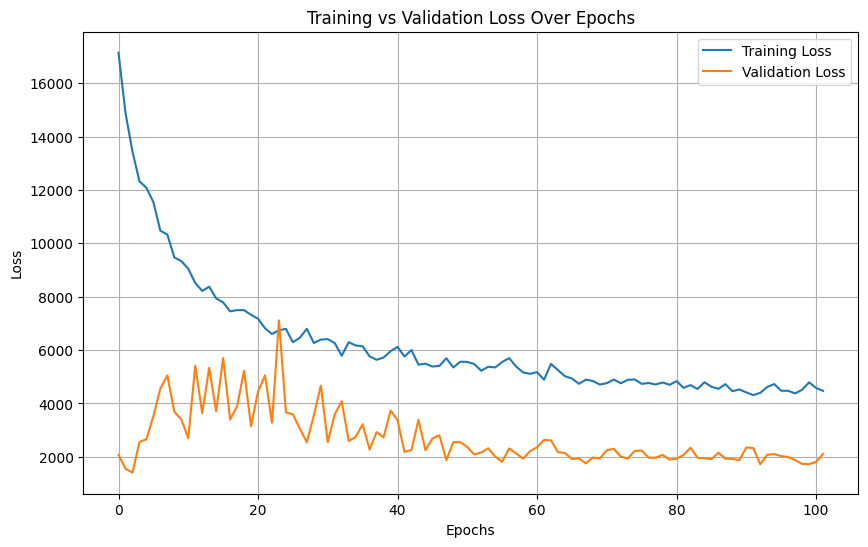

In [35]:
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'][1 : ], label='Training Loss')
plt.plot(history.history['val_loss'][1 : ], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss Over Epochs')
plt.legend()
plt.grid(True)
plt.show()

## LSTM & CONV Ensemble

In [36]:
def prepare_result(lstm_predictions, conv_predictions, conv_lstm_predictions, y_true, dates):
    global items_list
    global stores_list
    df = []
    lstm_predictions = lstm_predictions.reshape(len(items_list), -1)
    conv_predictions = conv_predictions.reshape(len(items_list), -1)
    conv_lstm_predictions = conv_lstm_predictions.reshape(len(items_list), -1)
    dates = dates.reshape(len(items_list), -1)
    y_true = y_true.reshape(len(items_list), -1)
    for i in range(len(items_list)):
#         for j in range(len(stores_list)):
        for k in range(1, lstm_predictions.shape[1]): 
            df.append(
                pd.DataFrame(
                    {
                        "item_id" : [items_list[i]],
#                         "store_id" : [stores_list[j]],
                        "actual" : [y_true[i][k - 1]],
                        "conv_predictions" : [conv_predictions[i][k - 1]],
                        "lstm_predictions" : [lstm_predictions[i][k - 1]],
                        "conv_lstm_predictions" : [conv_lstm_predictions[i][k - 1]],
                        "week" : [k], 
                        "week_date" : [dates[i][k - 1]]
                    }
                )
            )
    df = pd.concat(df, axis = 0, ignore_index = True)
    return df

In [37]:
from sklearn.metrics import mean_squared_error

In [38]:
alphas = np.linspace(-1, 1, 100)
train_result = prepare_result(lstm_model.predict(X_train), conv_model.predict(X_train), conv_lstm_model.predict(X_train.reshape(-1, 1, lookback_window, len(feature_columns))), Y_train, dates_train)

best_loss = 1e+6
best_alpha = 0
for alpha in alphas:
    preds = alpha * train_result["conv_predictions"].values + (1 - alpha) * train_result["lstm_predictions"].values 
    loss = mean_squared_error(train_result["actual"].values, preds)
    if loss < best_loss:
        best_loss = loss
        best_alpha = alpha

print(best_alpha)

1673/1673 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
1673/1673 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
1673/1673 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step
0.6767676767676769


## Save Model Predictions 

In [39]:
df = []
lstm_predictions = lstm_model.predict(X_eval).reshape(len(items_list), -1)
conv_predictions = conv_model.predict(X_eval).reshape(len(items_list), -1)
conv_lstm_predictions = conv_lstm_model.predict(X_eval.reshape(-1, 1, lookback_window, len(feature_columns))).reshape(len(items_list), -1)
dates_eval = dates_eval.reshape(len(items_list), -1)
y_true = Y_eval.reshape(len(items_list), -1)
for i in range(len(items_list)):
#     for j in range(len(stores_list)):
    for k in range(1, 5): 
        df.append(
            pd.DataFrame(
                {
                    "item_id" : [items_list[i]],
#                     "store_id" : [stores_list[j]],
                    "actual" : [y_true[i][k - 1]],
                    "conv_predictions" : [conv_predictions[i][k - 1]],
                    "lstm_predictions" : [lstm_predictions[i][k - 1]],
                    "conv_lstm_predictions" : [conv_lstm_predictions[i][k - 1]],
                    "week" : [k], 
                    "week_date" : [dates_eval[i][k - 1]]
                }
            )
        )
df = pd.concat(df, axis = 0, ignore_index = True)

df["ensemble_predictions"] = best_alpha * df["conv_predictions"].values + (1 - best_alpha) * df["lstm_predictions"].values
train_result["ensemble_predictions"] = best_alpha * train_result["conv_predictions"].values + (1 - best_alpha) * train_result["lstm_predictions"].values

29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


# In-Stock Probability and Fill Rate Calculation

In [40]:
# Mean & stdev of Demand is calculated from training set.
# Order Quantity is taken as the demand forecast -> Assuming the Demand = Supply. 
def calculate_in_stock_probability(mean_demand, std_dev, order_quantity):
    # Calculate the Z-score
    z_score = (order_quantity - mean_demand) / (std_dev + 1e-6)
    
    # Calculate the cumulative probability using the standard normal distribution
    in_stock_probability = stats.norm.cdf(z_score)
    
    return in_stock_probability

def calculate_fill_rate(mean_demand, std_dev, order_quantity):
    # Calculate the Z-score
    z_score = (order_quantity - mean_demand) / (std_dev + 1e-6)
    
    # Calculate the expected shortage using the standard normal loss function
    loss_function = stats.norm.pdf(z_score) - z_score * stats.norm.cdf(z_score)
    expected_shortage = std_dev * loss_function
    
    # Calculate the fill rate
    fill_rate = 1 - (expected_shortage / (mean_demand + 1e-6))
    
    return fill_rate

In [41]:
mean = train_result.groupby("item_id")["actual"].mean().reset_index().rename(columns = {"actual" : "mean_demand"})
std = train_result.groupby("item_id")["actual"].std().reset_index().rename(columns = {"actual" : "stdev_demand"})

df = df.merge(mean, on = "item_id", how = "inner")
df = df.merge(std, on = "item_id", how = "inner")

train_result = train_result.merge(mean, on = "item_id", how = "inner")
train_result = train_result.merge(std, on = "item_id", how = "inner")

In [42]:
df["in_stock_p"] = df.apply(lambda row: calculate_in_stock_probability(row["mean_demand"], row["stdev_demand"], row["ensemble_predictions"]), axis = 1)
df["fill_rate"] = df.apply(lambda row: calculate_fill_rate(row["mean_demand"], row["stdev_demand"], row["ensemble_predictions"]), axis = 1)

train_result["in_stock_p"] = train_result.apply(lambda row: calculate_in_stock_probability(row["mean_demand"], row["stdev_demand"], row["ensemble_predictions"]), axis = 1)
train_result["fill_rate"] = train_result.apply(lambda row: calculate_fill_rate(row["mean_demand"], row["stdev_demand"], row["ensemble_predictions"]), axis = 1)

In [43]:
train_result.to_csv("train_predictions.csv", index = False)

In [44]:
df.to_csv("eval_predictions.csv", index = False)
df

,item_id,actual,conv_predictions,lstm_predictions,conv_lstm_predictions,week,week_date,ensemble_predictions,mean_demand,stdev_demand,in_stock_p,fill_rate
0,FOODS_1_001,74.0,65.026649,111.395164,61.303978,1,2016-04-02,80.014450,33.222617,32.106309,0.927497,2.173015
1,FOODS_1_001,64.0,42.203335,106.731773,60.881630,2,2016-04-02,63.061012,33.222617,32.106309,0.823649,1.489418
2,FOODS_1_001,60.0,59.537106,112.573288,49.427490,3,2016-04-02,76.680115,33.222617,32.106309,0.912060,2.038786
3,FOODS_1_001,56.0,41.030930,106.363197,57.660477,4,2016-04-02,62.148430,33.222617,32.106309,0.816190,1.453701
4,FOODS_1_002,51.0,57.851273,103.710526,53.813133,1,2016-04-02,72.674469,24.263364,15.564975,0.999065,2.991340
5,FOODS_1_002,50.0,39.552830,109.731766,53.053711,2,2016-04-02,62.236931,24.263364,15.564975,0.992650,2.540503
6,FOODS_1_002,45.0,61.871773,91.160423,51.523041,3,2016-04-02,71.338806,24.263364,15.564975,0.998755,2.935128
7,FOODS_1_002,39.0,49.956715,105.298103,51.024956,4,2016-04-02,67.844841,24.263364,15.564975,0.997445,2.786516
8,FOODS_1_003,78.0,62.189564,108.155975,57.551758,1,2016-04-02,77.047394,36.755140,30.004042,0.910347,1.865770
9,FOODS_1_003,72.0,47.282246,106.377007,51.489563,2,2016-04-02,66.383583,36.755140,30.004042,0.838297,1.475755
